# EDA

In [35]:
#importation des packages 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [36]:
# importation des données
df = pd.read_csv(r"C:\Users\yacin\Desktop\Analyse financière entreprises\ratios_inpi_bce.csv", sep = ";")

In [37]:
df.head()

,siren,date_cloture_exercice,Chiffre_d_affaires,Marge_brute,EBE,EBIT,Resultat_net,Taux_d_endettement,Ratio_de_liquidite,Ratio_de_vetuste,...,CAF_sur_CA,Capacite_de_remboursement,Marge_EBE,Resultat_courant_avant_impots_sur_CA,Poids_BFR_exploitation_sur_CA_jours,Rotation_des_stocks_jours,Credit_clients_Jours,Credit_fournisseurs_Jours,type_bilan,confidentiality
0,493287213,2016-08-31,2078915,316815,44407,36895,35656,0.146,160.886,3.615,...,1.964,0.009,2.136,1.808,46.560,11.036,33.982,58.937,C,Public
1,493287338,2020-12-31,63890,63890,-13232,-10542,-10542,3.915,466.802,0.000,...,-16.500,0.000,-20.711,-16.500,53.084,0.000,87.051,24.323,S,Public
2,493287510,2021-10-31,0,0,0,0,53454,83.014,147.366,47.340,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,C,Partiellement confidentiel
3,493287734,2024-12-31,47394,47394,26046,25293,27129,213.900,188.753,70.660,...,55.750,14.102,54.956,48.681,1046.874,0.000,304.817,460.353,C,Public
4,493288013,2021-12-31,527485,527485,53558,56743,33450,217.293,272.813,NaN,...,5.738,3.311,10.153,10.757,32.516,0.000,86.666,40.709,C,Public


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6051701 entries, 0 to 6051700
Data columns (total 23 columns):
 #   Column                                Dtype  
---  ------                                -----  
 0   siren                                 int64  
 1   date_cloture_exercice                 object 
 2   Chiffre_d_affaires                    int64  
 3   Marge_brute                           int64  
 4   EBE                                   int64  
 5   EBIT                                  int64  
 6   Resultat_net                          int64  
 7   Taux_d_endettement                    float64
 8   Ratio_de_liquidite                    float64
 9   Ratio_de_vetuste                      float64
 10  Autonomie_financiere                  float64
 11  Poids_BFR_exploitation_sur_CA         float64
 12  Couverture_des_interets               float64
 13  CAF_sur_CA                            float64
 14  Capacite_de_remboursement             float64
 15  Marge_EBE      

In [39]:
cols_to_convert = [
    "Chiffre_d_affaires",
    "Marge_brute",
    "EBE",
    "EBIT",
    "Resultat_net"
]

df[cols_to_convert] = df[cols_to_convert].astype(float)


In [40]:
df["date_cloture_exercice"] = pd.to_datetime(df["date_cloture_exercice"], errors="coerce")


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6051701 entries, 0 to 6051700
Data columns (total 23 columns):
 #   Column                                Dtype         
---  ------                                -----         
 0   siren                                 int64         
 1   date_cloture_exercice                 datetime64[ns]
 2   Chiffre_d_affaires                    float64       
 3   Marge_brute                           float64       
 4   EBE                                   float64       
 5   EBIT                                  float64       
 6   Resultat_net                          float64       
 7   Taux_d_endettement                    float64       
 8   Ratio_de_liquidite                    float64       
 9   Ratio_de_vetuste                      float64       
 10  Autonomie_financiere                  float64       
 11  Poids_BFR_exploitation_sur_CA         float64       
 12  Couverture_des_interets               float64       
 13  CAF_sur_CA  

In [42]:
df.isna().sum()

siren                                         0
date_cloture_exercice                         0
Chiffre_d_affaires                            0
Marge_brute                                   0
EBE                                           0
EBIT                                          0
Resultat_net                                  0
Taux_d_endettement                         4383
Ratio_de_liquidite                        96008
Ratio_de_vetuste                        1223429
Autonomie_financiere                       2383
Poids_BFR_exploitation_sur_CA           2105628
Couverture_des_interets                 1415158
CAF_sur_CA                              2100644
Capacite_de_remboursement               1412867
Marge_EBE                               2098440
Resultat_courant_avant_impots_sur_CA    2098440
Poids_BFR_exploitation_sur_CA_jours     2105628
Rotation_des_stocks_jours               2105628
Credit_clients_Jours                    1960220
Credit_fournisseurs_Jours               

In [43]:
df.duplicated().sum()

0

In [48]:
df["date_cloture_exercice"].min(), df["date_cloture_exercice"].max()

(Timestamp('1919-09-30 00:00:00'), Timestamp('2026-02-06 00:00:00'))

## Dataviz

<Axes: xlabel='annee', ylabel='Chiffre_d_affaires'>

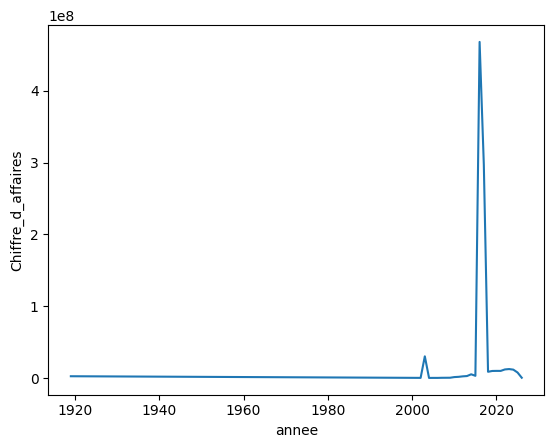

In [ ]:
df["annee"] = df["date_cloture_exercice"].dt.year
df_agg = df.groupby("annee")["Chiffre_d_affaires"].mean().reset_index()

sns.lineplot(data=df_agg, x="annee", y="Chiffre_d_affaires")
